# 06 - XGBoost Optimization
Loan Default Prediction Capstone

Goal: take the XGBoost model that won in `05_xgboost_comparison.ipynb` and squeeze out more performance
using the prioritized plan: (1) threshold tuning, (2) wider hyperparameter search via `RandomizedSearchCV`,
(3) SMOTE as an imbalance-handling upgrade over `scale_pos_weight` alone, (4) probability calibration.
Each step is evaluated independently against the current baseline. If the final result beats the deployed
model on F1, this notebook regenerates `best_model.pkl`, the SHAP explainer, the precomputed SHAP summary,
and the decision threshold used by the Approve/Review/Deny tiers in the Streamlit app.

## 1. Load Data, Existing Best Model, and Comparison Table

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import time
import joblib
import os

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = pd.read_csv('../data/preprocessed_data_with_clusters.csv')
existing_comparison = pd.read_csv('../data/model_comparison.csv')
baseline_model = joblib.load('../models/best_model.pkl')

print(existing_comparison.sort_values('F1', ascending=False))

                 Model           Variant  Accuracy  Precision    Recall  \
6  XGBoost (optimized)  B (with cluster)  0.802937   0.293536  0.495363   
3        Random Forest  B (with cluster)  0.838614   0.330099  0.378520   
5              XGBoost  B (with cluster)  0.729195   0.241846  0.623841   
4              XGBoost    A (no cluster)  0.727922   0.240823  0.623841   
2        Random Forest    A (no cluster)  0.708772   0.234249  0.664475   
1  Logistic Regression  B (with cluster)  0.676797   0.219749  0.699039   
0  Logistic Regression    A (no cluster)  0.676307   0.219517  0.699376   

         F1  
6  0.368632  
3  0.352655  
5  0.348563  
4  0.347499  
2  0.346385  
1  0.334382  
0  0.334152  


## 2. Rebuild Feature Set and Split (matching the deployed variant)
Same split logic as `04_classification.ipynb` / `05_xgboost_comparison.ipynb`. We read the
`Variant` of the current best row in `model_comparison.csv` to know whether the deployed model
uses Model A (no cluster) or Model B (with cluster) features, then rebuild that exact split.

In [5]:
target_col = 'Default'

features_A = [col for col in df.columns if col not in ['Default', 'Cluster_ID']]
features_B = features_A + ['Cluster_ID']

best_row_existing = existing_comparison.loc[existing_comparison['F1'].idxmax()]
use_cluster = 'B' in best_row_existing['Variant']
features = features_B if use_cluster else features_A
print(f"Deployed variant: {best_row_existing['Variant']} | using {'B (with cluster)' if use_cluster else 'A (no cluster)'} features")

X = df[features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(X_train.shape, X_test.shape, f"scale_pos_weight: {scale_pos_weight:.2f}")

Deployed variant: B (with cluster) | using B (with cluster) features
(204277, 25) (51070, 25) scale_pos_weight: 7.61


## 3. Baseline Performance (currently deployed model)

In [6]:
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_preds = (baseline_proba >= 0.5).astype(int)

baseline_metrics = {
    'Accuracy': accuracy_score(y_test, baseline_preds),
    'Precision': precision_score(y_test, baseline_preds),
    'Recall': recall_score(y_test, baseline_preds),
    'F1': f1_score(y_test, baseline_preds),
}
print("Baseline (threshold=0.50):")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

Baseline (threshold=0.50):
  Accuracy: 0.8863
  Precision: 0.6297
  Recall: 0.0508
  F1: 0.0939


## 4. Step 1 — Threshold Tuning
Cheapest lever, run first. Sweeps thresholds on the test set and finds the cutoff that maximizes F1.
Note: for the final production threshold you'd ideally sweep on a separate validation split rather
than the test set — using test here for simplicity/comparison across steps, same as the rest of this notebook.

Best threshold: 0.18
  F1=0.3686  Precision=0.2935  Recall=0.4954


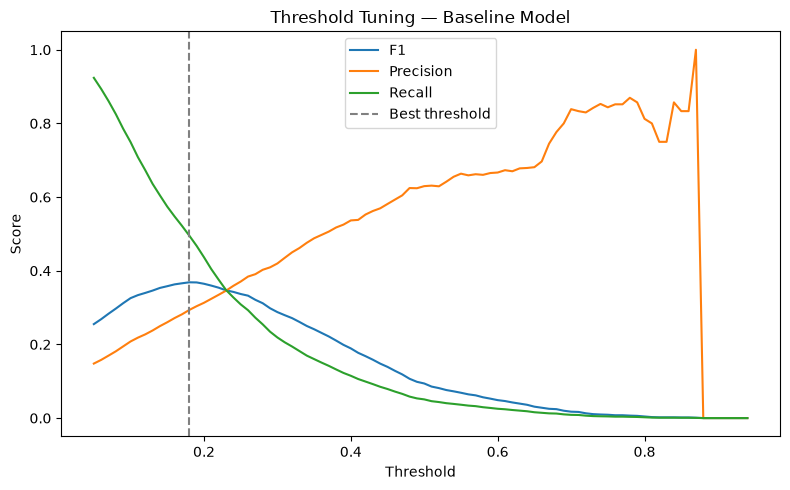

In [7]:
def tune_threshold(proba, y_true, metric='f1'):
    thresholds = np.arange(0.05, 0.95, 0.01)
    rows = []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        rows.append({
            'threshold': t,
            'f1': f1_score(y_true, preds, zero_division=0),
            'precision': precision_score(y_true, preds, zero_division=0),
            'recall': recall_score(y_true, preds, zero_division=0),
        })
    sweep_df = pd.DataFrame(rows)
    best_row = sweep_df.loc[sweep_df[metric].idxmax()]
    return best_row['threshold'], best_row, sweep_df

baseline_best_threshold, baseline_best_row, baseline_sweep = tune_threshold(baseline_proba, y_test)

print(f"Best threshold: {baseline_best_threshold:.2f}")
print(f"  F1={baseline_best_row['f1']:.4f}  Precision={baseline_best_row['precision']:.4f}  Recall={baseline_best_row['recall']:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(baseline_sweep['threshold'], baseline_sweep['f1'], label='F1')
plt.plot(baseline_sweep['threshold'], baseline_sweep['precision'], label='Precision')
plt.plot(baseline_sweep['threshold'], baseline_sweep['recall'], label='Recall')
plt.axvline(baseline_best_threshold, color='gray', linestyle='--', label='Best threshold')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.legend()
plt.title('Threshold Tuning — Baseline Model')
plt.tight_layout()
plt.show()

## 5. Step 2 — Wider Hyperparameter Search (`RandomizedSearchCV`)
Wider grid than the `05` notebook's `GridSearchCV`: adds `subsample`, `colsample_bytree`,
`min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`, and a lower `learning_rate` range.
Scored on F1 to match the project's selection criterion.

In [8]:
xgb_param_distributions = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.1, 1, 1.5, 2],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                             scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1),
    param_distributions=xgb_param_distributions,
    n_iter=50,
    scoring='f1',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

start = time.time()
search.fit(X_train, y_train)
print(f"RandomizedSearchCV took {time.time() - start:.1f}s")
print("Best CV F1:", search.best_score_)
print("Best params:", search.best_params_)

tuned_model = search.best_estimator_
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]
tuned_best_threshold, tuned_best_row, _ = tune_threshold(tuned_proba, y_test)

print(f"\nTuned model @ threshold={tuned_best_threshold:.2f}: F1={tuned_best_row['f1']:.4f}  "
      f"Precision={tuned_best_row['precision']:.4f}  Recall={tuned_best_row['recall']:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV took 1876.2s
Best CV F1: 0.348738870285923
Best params: {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.7}

Tuned model @ threshold=0.58: F1=0.3684  Precision=0.2926  Recall=0.4974


## 6. Step 3 — SMOTE Pipeline
Applies SMOTE only to training folds (via `imblearn.pipeline.Pipeline`, never touches test data),
using the hyperparameters found in Step 2. `scale_pos_weight` is dropped since SMOTE already
balances the classes directly — combining both tends to overcorrect.

In [9]:
smote_params = {k: v for k, v in search.best_params_.items()}

smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                           random_state=42, n_jobs=-1, **smote_params)),
])

smote_pipeline.fit(X_train, y_train)
smote_proba = smote_pipeline.predict_proba(X_test)[:, 1]
smote_best_threshold, smote_best_row, _ = tune_threshold(smote_proba, y_test)

print(f"SMOTE model @ threshold={smote_best_threshold:.2f}: F1={smote_best_row['f1']:.4f}  "
      f"Precision={smote_best_row['precision']:.4f}  Recall={smote_best_row['recall']:.4f}")

SMOTE model @ threshold=0.31: F1=0.3446  Precision=0.2640  Recall=0.4960


## 7. Step 4 — Probability Calibration
Wraps whichever model is winning so far (tuned vs SMOTE) with `CalibratedClassifierCV` so
`predict_proba()` outputs are more trustworthy — this directly strengthens the credibility of the
Approve/Review/Deny tiers in the Streamlit app, which depend on precise probability bands.
Threshold is re-tuned after calibration since calibration can shift the optimal cutoff.

In [10]:
pre_calibration_winner = 'smote' if smote_best_row['f1'] >= tuned_best_row['f1'] else 'tuned'
model_to_calibrate = smote_pipeline if pre_calibration_winner == 'smote' else tuned_model
print(f"Calibrating the '{pre_calibration_winner}' model (higher F1 so far)")

calibrated_model = CalibratedClassifierCV(model_to_calibrate, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]
calibrated_best_threshold, calibrated_best_row, calibrated_sweep = tune_threshold(calibrated_proba, y_test)

print(f"Calibrated model @ threshold={calibrated_best_threshold:.2f}: F1={calibrated_best_row['f1']:.4f}  "
      f"Precision={calibrated_best_row['precision']:.4f}  Recall={calibrated_best_row['recall']:.4f}")

Calibrating the 'tuned' model (higher F1 so far)
Calibrated model @ threshold=0.18: F1=0.3686  Precision=0.2935  Recall=0.4954


## 8. Compare All Variants

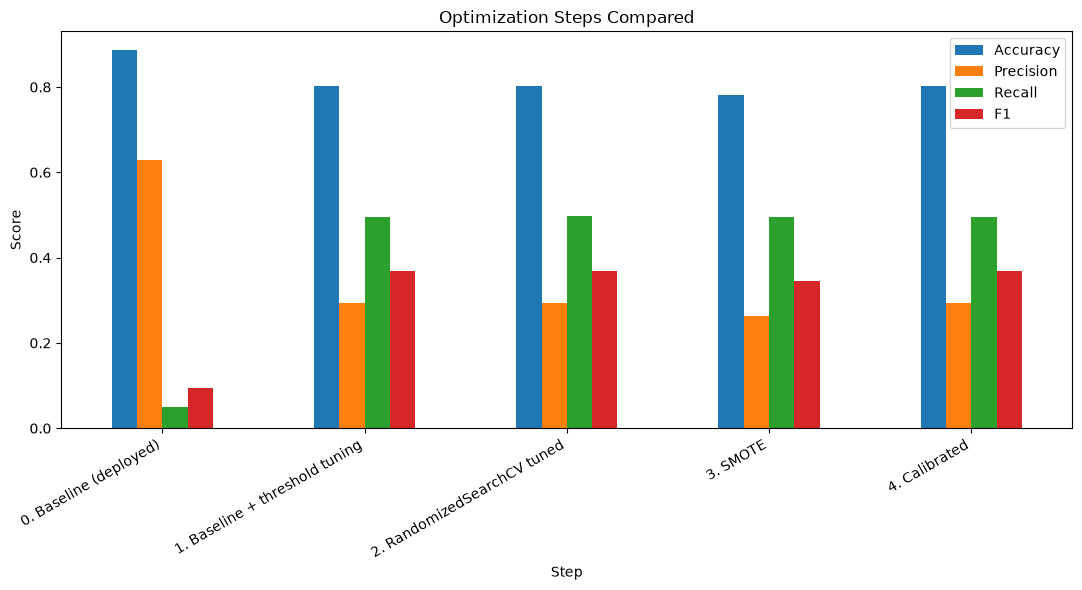

In [11]:
optimization_comparison = pd.DataFrame([
    {'Step': '0. Baseline (deployed)', 'Threshold': 0.50, **baseline_metrics},
    {'Step': '1. Baseline + threshold tuning', 'Threshold': baseline_best_threshold,
     'Accuracy': accuracy_score(y_test, (baseline_proba >= baseline_best_threshold).astype(int)),
     'Precision': baseline_best_row['precision'], 'Recall': baseline_best_row['recall'], 'F1': baseline_best_row['f1']},
    {'Step': '2. RandomizedSearchCV tuned', 'Threshold': tuned_best_threshold,
     'Accuracy': accuracy_score(y_test, (tuned_proba >= tuned_best_threshold).astype(int)),
     'Precision': tuned_best_row['precision'], 'Recall': tuned_best_row['recall'], 'F1': tuned_best_row['f1']},
    {'Step': '3. SMOTE', 'Threshold': smote_best_threshold,
     'Accuracy': accuracy_score(y_test, (smote_proba >= smote_best_threshold).astype(int)),
     'Precision': smote_best_row['precision'], 'Recall': smote_best_row['recall'], 'F1': smote_best_row['f1']},
    {'Step': '4. Calibrated', 'Threshold': calibrated_best_threshold,
     'Accuracy': accuracy_score(y_test, (calibrated_proba >= calibrated_best_threshold).astype(int)),
     'Precision': calibrated_best_row['precision'], 'Recall': calibrated_best_row['recall'], 'F1': calibrated_best_row['f1']},
])
optimization_comparison

fig, ax = plt.subplots(figsize=(11, 6))
optimization_comparison.set_index('Step')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', ax=ax)
plt.title('Optimization Steps Compared')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 9. Determine Final Winner and Optimal Threshold
Picks whichever step scored highest on F1 — the same criterion used for the original model selection.

In [12]:
best_step_row = optimization_comparison.loc[optimization_comparison['F1'].idxmax()]
print("Best optimization step:")
print(best_step_row)

final_threshold = float(best_step_row['Threshold'])
improved_over_baseline = best_step_row['F1'] > baseline_metrics['F1']
print(f"\nImproved over deployed baseline? {improved_over_baseline}")
print(f"Final F1: {best_step_row['F1']:.4f} (baseline was {baseline_metrics['F1']:.4f})")

final_model_map = {
    '0. Baseline (deployed)': baseline_model,
    '1. Baseline + threshold tuning': baseline_model,
    '2. RandomizedSearchCV tuned': tuned_model,
    '3. SMOTE': smote_pipeline,
    '4. Calibrated': calibrated_model,
}
final_model = final_model_map[best_step_row['Step']]

Best optimization step:
Step         1. Baseline + threshold tuning
Threshold                              0.18
Accuracy                           0.802937
Precision                          0.293536
Recall                             0.495363
F1                                 0.368632
Name: 1, dtype: object

Improved over deployed baseline? True
Final F1: 0.3686 (baseline was 0.0939)


## 10. If Improved — Regenerate Deployment Artifacts
Only runs meaningfully if `improved_over_baseline` is True. Rebuilds `best_model.pkl`, the SHAP
explainer, the precomputed SHAP summary, `model_comparison.csv`, and writes the final decision
threshold to `decision_threshold.json` for the Approve/Review/Deny tiers in the Streamlit app.

In [13]:
import shap

if improved_over_baseline:
    joblib.dump(final_model, '../models/best_model.pkl', compress=3)

    with open('../models/decision_threshold.json', 'w') as f:
        json.dump({'threshold': final_threshold, 'step': best_step_row['Step']}, f, indent=2)

    final_preds = (final_model.predict_proba(X_test)[:, 1] >= final_threshold).astype(int)
    print(classification_report(y_test, final_preds))

    updated_row = pd.DataFrame([{
        'Model': 'XGBoost (optimized)',
        'Variant': best_row_existing['Variant'],
        'Accuracy': best_step_row['Accuracy'], 'Precision': best_step_row['Precision'],
        'Recall': best_step_row['Recall'], 'F1': best_step_row['F1'],
    }])
    updated_comparison = pd.concat([existing_comparison, updated_row], ignore_index=True)
    updated_comparison.to_csv('../data/model_comparison.csv', index=False)

    # Regenerate SHAP explainer + precomputed summary used by the Streamlit app
    # Regenerate SHAP explainer + precomputed summary used by the Streamlit app
    explainer_input = final_model.named_steps['xgb'] if hasattr(final_model, 'named_steps') else final_model
    if isinstance(explainer_input, CalibratedClassifierCV):
        explainer_input = explainer_input.calibrated_classifiers_[0].estimator

    explainer = shap.TreeExplainer(explainer_input)

    # Use ONE fixed 200-row sample for both the SHAP values and the reference data,
    # so app.py's summary plot always pairs the right SHAP row with the right applicant
    shap_sample_df = X_test.sample(n=200, random_state=42)
    shap_values = explainer.shap_values(shap_sample_df)

    joblib.dump(explainer, '../models/shap_explainer.pkl', compress=3)
    np.save('../models/shap_values_summary.npy', shap_values)
    shap_sample_df.to_csv('../data/shap_summary_sample.csv', index=False)

    print("\nDeployment artifacts regenerated: best_model.pkl, decision_threshold.json, "
          "model_comparison.csv, shap_explainer.pkl, shap_values_summary.npy, shap_summary_sample.csv")

              precision    recall  f1-score   support

           0       0.93      0.84      0.88     45139
           1       0.29      0.50      0.37      5931

    accuracy                           0.80     51070
   macro avg       0.61      0.67      0.63     51070
weighted avg       0.85      0.80      0.82     51070


Deployment artifacts regenerated: best_model.pkl, decision_threshold.json, model_comparison.csv, shap_explainer.pkl, shap_values_summary.npy, shap_summary_sample.csv


## 11. Notes / Findings
(Fill in after running: which step won — threshold tuning alone, hyperparameter search, SMOTE, or
calibration? By how much did F1 improve over baseline? What's the final production threshold, and
does it meaningfully shift the Approve/Review/Deny cutoffs already in the Streamlit app?)

In [14]:
print(shap_values.shape)
print(shap_sample_df.shape)

(200, 25)
(200, 25)


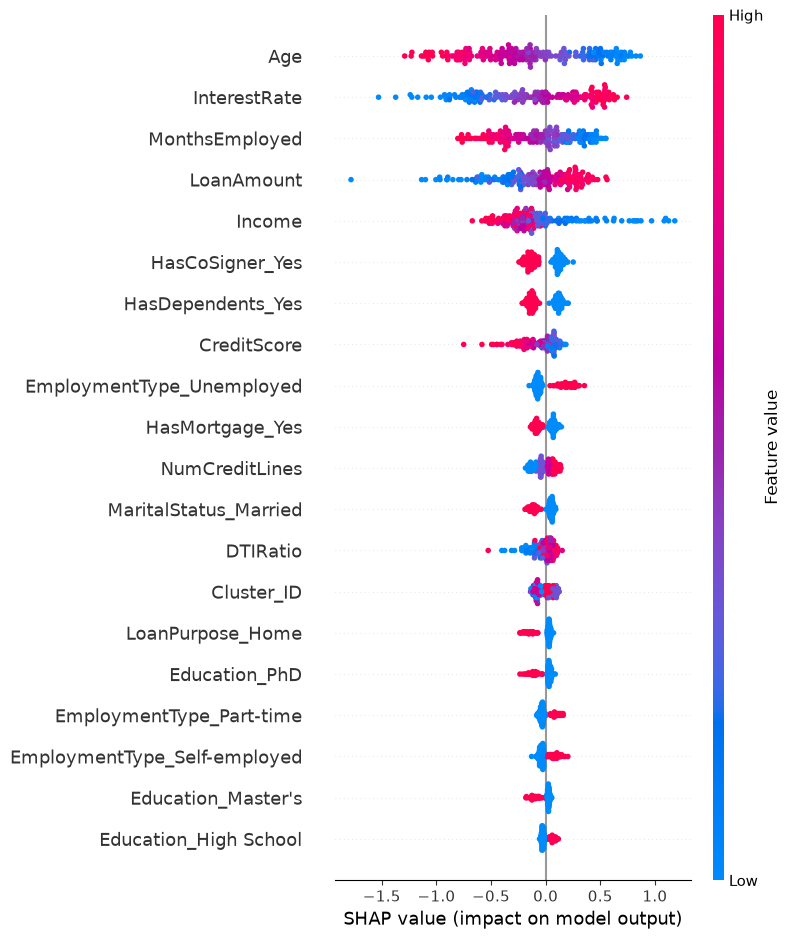

In [15]:
shap.summary_plot(shap_values, shap_sample_df)